In [6]:
# 1. Bibliotheken laden
import pandas as pd
import sqlalchemy as sa
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Verbinding maken
engine = sa.create_engine("mysql+pymysql://root:@localhost/climate_watch")

df_global_clean = pd.read_sql("SELECT * FROM cleaned_global_temperatures", engine)

# Gebruik van describe() voor de algemene statistieken (Opdracht 4.1)
# Focus op de belangrijkste temperatuur-kolommen
stats = df_global_clean[['LandAverageTemperature', 'LandMaxTemperature', 'LandMinTemperature', 'LandAndOceanAverageTemperature']].describe()

# Toevoegen van de Mediaan (median) omdat describe() deze niet standaard toont (behalve als 50%)
median = df_global_clean[['LandAverageTemperature', 'LandMaxTemperature', 'LandMinTemperature', 'LandAndOceanAverageTemperature']].median()
stats.loc['median'] = median

display(stats)

,LandAverageTemperature,LandMaxTemperature,LandMinTemperature,LandAndOceanAverageTemperature
count,432.000000,432.000000,432.000000,432.000000
mean,9.259451,14.964331,3.644563,15.655507
std,4.138503,4.252582,4.012910,1.229815
min,2.558000,8.090000,-2.853000,13.566000
25%,5.217000,10.710500,-0.296500,14.443500
50%,9.480500,15.207500,3.762000,15.732000
75%,13.224000,19.076250,7.500500,16.814250
max,15.482000,21.320000,9.715000,17.611000
median,9.480500,15.207500,3.762000,15.732000


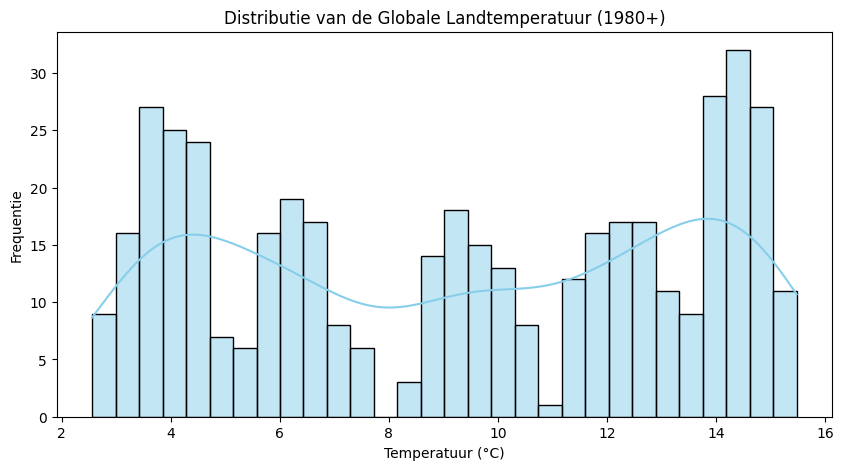

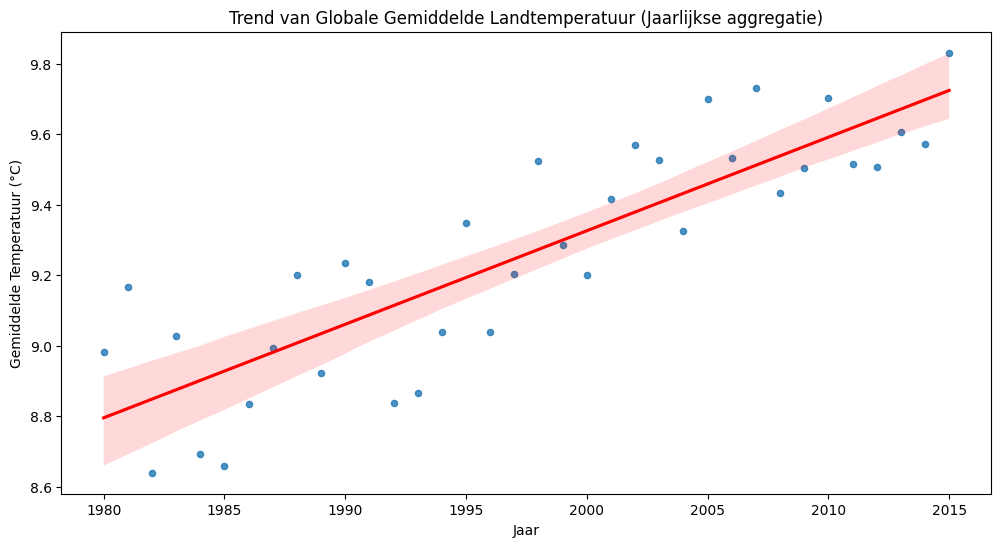

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Zorg dat 'dt' een datetime object is
df_global_clean['dt'] = pd.to_datetime(df_global_clean['dt'])

# 1. Distributie van de temperatuur (Histogram)
plt.figure(figsize=(10, 5))
sns.histplot(df_global_clean['LandAverageTemperature'], bins=30, kde=True, color='skyblue')
plt.title('Distributie van de Globale Landtemperatuur (1980+)')
plt.xlabel('Temperatuur (°C)')
plt.ylabel('Frequentie')
plt.show()

# 2. Jaarlijkse groepering (Opdracht 4.2)
# Groepering per jaar om de seizoensinvloeden te middelen
df_yearly = df_global_clean.groupby(df_global_clean['dt'].dt.year)['LandAverageTemperature'].mean().reset_index()

# 3. Visualisatie van de trend (Opdracht 4.3)
plt.figure(figsize=(12, 6))
sns.regplot(data=df_yearly, x='dt', y='LandAverageTemperature', scatter_kws={'s':20}, line_kws={'color':'red'})
plt.title('Trend van Globale Gemiddelde Landtemperatuur (Jaarlijkse aggregatie)')
plt.xlabel('Jaar')
plt.ylabel('Gemiddelde Temperatuur (°C)')
plt.show()